<a href="https://colab.research.google.com/github/jferreira04-cloud/Calculo_num-rico_lobosco/blob/main/atividade_sistemas_lineares.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Bibliotecas usadas em todo o notebook
import numpy as np
import matplotlib.pyplot as plt

# Exibição mais limpa dos números: 4 casas decimais e sem notação científica
np.set_printoptions(precision=4, suppress=True)

---
# Parte 1 — Conceitos e resolução manual

## Exercício 1 — Sistemas lineares na forma matricial

Todo sistema linear pode ser escrito como $A\mathbf{x} = \mathbf{b}$, em que:

- $A$ é a **matriz dos coeficientes**: cada linha corresponde a uma equação e cada coluna a uma incógnita;
- $\mathbf{x}$ é o **vetor de incógnitas**;
- $\mathbf{b}$ é o **vetor independente** (os termos do lado direito das equações).

### a)

$$
\begin{cases} 2x + y = 7 \\ x - 3y = -5 \end{cases}
\quad\Longrightarrow\quad
\underbrace{\begin{bmatrix} 2 & 1 \\ 1 & -3 \end{bmatrix}}_{A}
\underbrace{\begin{bmatrix} x \\ y \end{bmatrix}}_{\mathbf{x}}
=
\underbrace{\begin{bmatrix} 7 \\ -5 \end{bmatrix}}_{\mathbf{b}}
$$

- Matriz dos coeficientes (2×2): $A = \begin{bmatrix} 2 & 1 \\ 1 & -3 \end{bmatrix}$
- Vetor de incógnitas: $\mathbf{x} = \begin{bmatrix} x \\ y \end{bmatrix}$
- Vetor independente: $\mathbf{b} = \begin{bmatrix} 7 \\ -5 \end{bmatrix}$

### b)

$$
\begin{cases} x + 2y - z = 2 \\ 3x - y + 2z = 9 \\ 2x + y + z = 7 \end{cases}
\quad\Longrightarrow\quad
\underbrace{\begin{bmatrix} 1 & 2 & -1 \\ 3 & -1 & 2 \\ 2 & 1 & 1 \end{bmatrix}}_{A}
\underbrace{\begin{bmatrix} x \\ y \\ z \end{bmatrix}}_{\mathbf{x}}
=
\underbrace{\begin{bmatrix} 2 \\ 9 \\ 7 \end{bmatrix}}_{\mathbf{b}}
$$

- Matriz dos coeficientes (3×3): $A = \begin{bmatrix} 1 & 2 & -1 \\ 3 & -1 & 2 \\ 2 & 1 & 1 \end{bmatrix}$
- Vetor de incógnitas: $\mathbf{x} = \begin{bmatrix} x \\ y \\ z \end{bmatrix}$
- Vetor independente: $\mathbf{b} = \begin{bmatrix} 2 \\ 9 \\ 7 \end{bmatrix}$

Observação: um coeficiente que não aparece na equação vale 1 (como em $x$ ou $y$ sozinhos) e o sinal acompanha o coeficiente ($-z$ entra como $-1$).

No código abaixo, os mesmos sistemas são montados com NumPy. A solução calculada é só uma verificação extra (o exercício pede apenas a forma matricial): em (a), $x = 16/7 \approx 2{,}2857$ e $y = 17/7 \approx 2{,}4286$; em (b), $(x, y, z) = (2, 1, 2)$.

In [ ]:
# Exercício 1 — representação matricial com NumPy

# a)  2x + y = 7  ;  x - 3y = -5
A1a = np.array([[2,  1],
                [1, -3]], dtype=float)   # matriz dos coeficientes
b1a = np.array([7, -5], dtype=float)     # vetor independente

# b)  x + 2y - z = 2  ;  3x - y + 2z = 9  ;  2x + y + z = 7
A1b = np.array([[1,  2, -1],
                [3, -1,  2],
                [2,  1,  1]], dtype=float)
b1b = np.array([2, 9, 7], dtype=float)

for item, A, b in [("a)", A1a, b1a), ("b)", A1b, b1b)]:
    print(f"Item {item}  A ({A.shape[0]}x{A.shape[1]}):")
    print(A)
    print("b =", b)
    # Verificação extra (não pedida no enunciado): solução do sistema
    print("Solução (verificação):", np.linalg.solve(A, b), "\n")

Item a)  A (2x2):
[[ 2.  1.]
 [ 1. -3.]]
b = [ 7. -5.]
Solução (verificação): [2.2857 2.4286] 

Item b)  A (3x3):
[[ 1.  2. -1.]
 [ 3. -1.  2.]
 [ 2.  1.  1.]]
b = [2. 9. 7.]
Solução (verificação): [2. 1. 2.] 



## Exercício 2 — Método da eliminação de Gauss

$$
\begin{cases} 2x + y - z = 8 \\ -3x - y + 2z = -11 \\ -2x + y + 2z = -3 \end{cases}
$$

**Matriz aumentada inicial** $[A \mid \mathbf{b}]$:

$$
\left[\begin{array}{rrr|r}
2 & 1 & -1 & 8 \\
-3 & -1 & 2 & -11 \\
-2 & 1 & 2 & -3
\end{array}\right]
$$

**Etapa 1 — zerar a coluna 1 abaixo do pivô $a_{11} = 2$.**

Multiplicadores: $m_{21} = \dfrac{-3}{2} = -1{,}5$ e $m_{31} = \dfrac{-2}{2} = -1$.

- $L_2 \leftarrow L_2 - m_{21}L_1 = L_2 + \tfrac{3}{2}L_1$: $\;(-3+3,\; -1+\tfrac32,\; 2-\tfrac32 \mid -11+12) = (0,\; \tfrac12,\; \tfrac12 \mid 1)$
- $L_3 \leftarrow L_3 - m_{31}L_1 = L_3 + L_1$: $\;(-2+2,\; 1+1,\; 2-1 \mid -3+8) = (0,\; 2,\; 1 \mid 5)$

$$
\left[\begin{array}{rrr|r}
2 & 1 & -1 & 8 \\
0 & \tfrac{1}{2} & \tfrac{1}{2} & 1 \\
0 & 2 & 1 & 5
\end{array}\right]
$$

**Etapa 2 — zerar a coluna 2 abaixo do pivô $a_{22} = \tfrac12$.**

Multiplicador: $m_{32} = \dfrac{2}{1/2} = 4$.

- $L_3 \leftarrow L_3 - 4L_2$: $\;(0,\; 2-2,\; 1-2 \mid 5-4) = (0,\; 0,\; -1 \mid 1)$

$$
\left[\begin{array}{rrr|r}
2 & 1 & -1 & 8 \\
0 & \tfrac{1}{2} & \tfrac{1}{2} & 1 \\
0 & 0 & -1 & 1
\end{array}\right]
$$

A matriz está na forma **triangular superior**.

**Substituição regressiva** (de baixo para cima):

1. $-z = 1 \;\Rightarrow\; z = -1$
2. $\tfrac12 y + \tfrac12 z = 1 \;\Rightarrow\; \tfrac12 y - \tfrac12 = 1 \;\Rightarrow\; y = 3$
3. $2x + y - z = 8 \;\Rightarrow\; 2x + 3 + 1 = 8 \;\Rightarrow\; x = 2$

$$
\boxed{(x,\; y,\; z) = (2,\; 3,\; -1)}
$$

**Verificação** nas equações originais:

- $2(2) + 3 - (-1) = 8$ ✓
- $-3(2) - 3 + 2(-1) = -11$ ✓
- $-2(2) + 3 + 2(-1) = -3$ ✓

A implementação em Python deste mesmo processo está no Exercício 4.

---
# Parte 2 — Propriedades e interpretação

## Exercício 3 — Número de soluções

Critério usado (Teorema de Rouché–Capelli): escalonamos a matriz aumentada e comparamos o posto de $A$, o posto de $[A \mid \mathbf{b}]$ e o número de incógnitas $n$.

| Situação | Classificação |
|---|---|
| $\text{posto}(A) = \text{posto}([A \mid \mathbf{b}]) = n$ | solução **única** (possível e determinado) |
| $\text{posto}(A) = \text{posto}([A \mid \mathbf{b}]) < n$ | **infinitas** soluções (possível e indeterminado) |
| $\text{posto}(A) < \text{posto}([A \mid \mathbf{b}])$ | **nenhuma** solução (impossível) |

Na prática: uma linha do tipo $[\,0 \;\; 0 \mid c\,]$ com $c \neq 0$ significa $0 = c$ (absurdo, sem solução); uma linha toda nula $[\,0 \;\; 0 \mid 0\,]$ significa $0 = 0$ (equação redundante, sobra variável livre).

### a) $\;x + y = 3,\;\; 2x + 2y = 6$

$$
\left[\begin{array}{rr|r} 1 & 1 & 3 \\ 2 & 2 & 6 \end{array}\right]
\xrightarrow{L_2 \leftarrow L_2 - 2L_1}
\left[\begin{array}{rr|r} 1 & 1 & 3 \\ 0 & 0 & 0 \end{array}\right]
$$

A segunda linha virou $0 = 0$, sempre verdadeira. Então $\text{posto}(A) = \text{posto}([A \mid \mathbf{b}]) = 1 < 2$: **infinitas soluções**.

Solução geral: $y = t$ (livre) e $x = 3 - t$, com $t \in \mathbb{R}$. Geometricamente, a segunda equação é o dobro da primeira: as duas retas são **coincidentes**.

### b) $\;x + y = 3,\;\; 2x + 2y = 7$

$$
\left[\begin{array}{rr|r} 1 & 1 & 3 \\ 2 & 2 & 7 \end{array}\right]
\xrightarrow{L_2 \leftarrow L_2 - 2L_1}
\left[\begin{array}{rr|r} 1 & 1 & 3 \\ 0 & 0 & 1 \end{array}\right]
$$

A segunda linha diz $0x + 0y = 1$, ou seja, $0 = 1$: absurdo. Aqui $\text{posto}(A) = 1 < \text{posto}([A \mid \mathbf{b}]) = 2$: **nenhuma solução**.

Geometricamente, $x + y = 3$ e $x + y = 3{,}5$ são retas **paralelas distintas** (mesma inclinação, sem ponto em comum).

### c) $\;x + y = 3,\;\; 2x - y = 0$

$$
\left[\begin{array}{rr|r} 1 & 1 & 3 \\ 2 & -1 & 0 \end{array}\right]
\xrightarrow{L_2 \leftarrow L_2 - 2L_1}
\left[\begin{array}{rr|r} 1 & 1 & 3 \\ 0 & -3 & -6 \end{array}\right]
$$

Há dois pivôs não nulos: $\text{posto}(A) = \text{posto}([A \mid \mathbf{b}]) = 2 = n$, logo **solução única**.

Substituição regressiva: $-3y = -6 \Rightarrow y = 2$; $\;x + 2 = 3 \Rightarrow x = 1$. Solução $(x, y) = (1, 2)$: as retas são **concorrentes** nesse ponto.

O código abaixo confirma a classificação calculando os postos com NumPy e desenha as retas de cada caso.

In [ ]:
# Exercício 3 — classificação pelo posto (Teorema de Rouché-Capelli)

def classificar_sistema(A, b):
    # Compara posto(A), posto([A|b]) e o número de incógnitas n
    A = np.array(A, dtype=float)
    Ab = np.column_stack((A, b))          # matriz aumentada [A | b]
    n = A.shape[1]                        # número de incógnitas
    posto_A = np.linalg.matrix_rank(A)
    posto_Ab = np.linalg.matrix_rank(Ab)

    if posto_A < posto_Ab:
        tipo = "nenhuma solução (sistema impossível)"
    elif posto_A == n:
        tipo = "solução única (sistema possível e determinado)"
    else:
        tipo = "infinitas soluções (sistema possível e indeterminado)"
    return posto_A, posto_Ab, tipo


sistemas_ex3 = {
    "a)": ([[1, 1], [2,  2]], [3, 6]),
    "b)": ([[1, 1], [2,  2]], [3, 7]),
    "c)": ([[1, 1], [2, -1]], [3, 0]),
}

for item, (A, b) in sistemas_ex3.items():
    pA, pAb, tipo = classificar_sistema(A, b)
    print(f"{item} posto(A) = {pA} | posto([A|b]) = {pAb}  ->  {tipo}")

a) posto(A) = 1 | posto([A|b]) = 1  ->  infinitas soluções (sistema possível e indeterminado)
b) posto(A) = 1 | posto([A|b]) = 2  ->  nenhuma solução (sistema impossível)
c) posto(A) = 2 | posto([A|b]) = 2  ->  solução única (sistema possível e determinado)


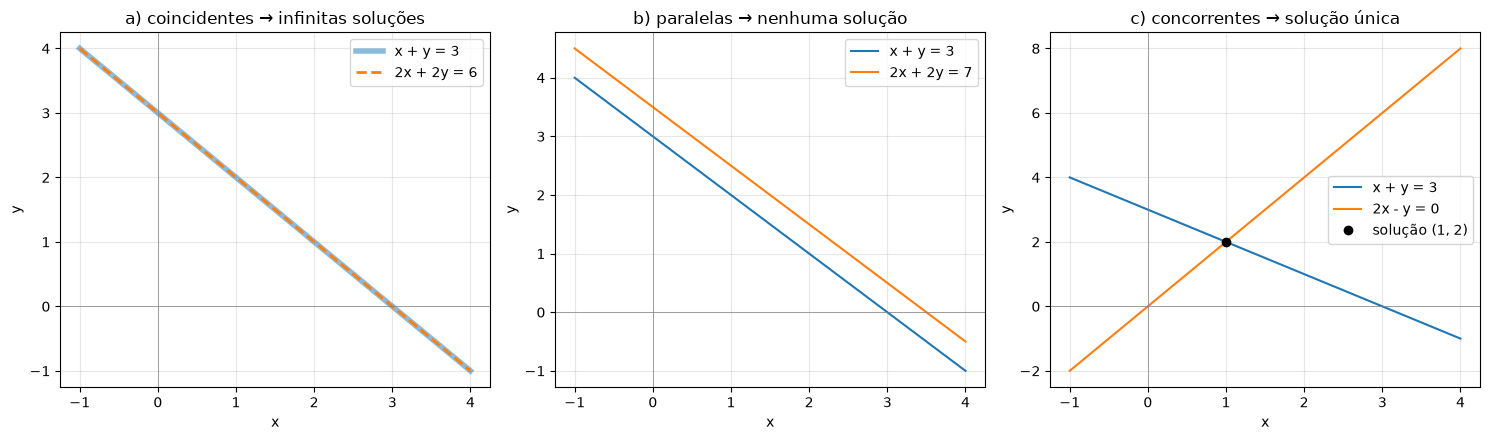

In [ ]:
# Interpretação geométrica: cada equação com 2 incógnitas é uma reta no plano

x = np.linspace(-1, 4, 100)
fig, eixos = plt.subplots(1, 3, figsize=(15, 4.5))

# a) retas coincidentes: y = 3 - x  e  2x + 2y = 6  (que também é y = 3 - x)
eixos[0].plot(x, 3 - x, lw=4, alpha=0.5, label="x + y = 3")
eixos[0].plot(x, (6 - 2*x) / 2, "--", lw=2, label="2x + 2y = 6")
eixos[0].set_title("a) coincidentes → infinitas soluções")

# b) retas paralelas: y = 3 - x  e  y = 3,5 - x
eixos[1].plot(x, 3 - x, label="x + y = 3")
eixos[1].plot(x, (7 - 2*x) / 2, label="2x + 2y = 7")
eixos[1].set_title("b) paralelas → nenhuma solução")

# c) retas concorrentes: y = 3 - x  e  y = 2x, que se cruzam em (1, 2)
eixos[2].plot(x, 3 - x, label="x + y = 3")
eixos[2].plot(x, 2*x, label="2x - y = 0")
eixos[2].plot(1, 2, "ko", label="solução (1, 2)")
eixos[2].set_title("c) concorrentes → solução única")

for ax in eixos:
    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="gray", lw=0.5)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

---
# Parte 3 — Implementação numérica em Python

## Exercício 4 — Eliminação de Gauss (sem pivoteamento)

A função `eliminacao_gauss` segue exatamente os passos pedidos:

1. **recebe** a matriz $A$ e o vetor $\mathbf{b}$;
2. **forma** a matriz aumentada $[A \mid \mathbf{b}]$;
3. **elimina** os elementos abaixo de cada pivô com $L_i \leftarrow L_i - m_{ik} L_k$, onde $m_{ik} = a_{ik} / a_{kk}$;
4. aplica a **substituição regressiva**: $x_i = \dfrac{b_i - \sum_{j>i} a_{ij} x_j}{a_{ii}}$, de $i = n$ até $i = 1$;
5. **exibe** a solução calculada.

Como o método é *sem pivoteamento* (não troca linhas), ele falha se algum pivô $a_{kk}$ for zero. Nesse caso a função interrompe com uma mensagem de erro em vez de dividir por zero.

In [ ]:
def eliminacao_gauss(A, b, nomes=None, mostrar_etapas=True):
    # Resolve Ax = b por eliminação de Gauss SEM pivoteamento.
    #   A              : matriz dos coeficientes (n x n)
    #   b              : vetor independente (n)
    #   nomes          : nomes das incógnitas para exibir (padrão: x1, x2, ...)
    #   mostrar_etapas : se True, imprime a matriz aumentada a cada etapa
    # Retorna o vetor solução x.

    # 1) Recebe A e b como arrays float (evita divisão inteira e
    #    não altera os dados originais de quem chamou a função)
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)
    n = len(b)
    if A.shape != (n, n):
        raise ValueError("A deve ser quadrada (n x n) e compatível com b.")
    if nomes is None:
        nomes = [f"x{i+1}" for i in range(n)]

    # 2) Forma a matriz aumentada [A | b]: n linhas e n+1 colunas
    Ab = np.column_stack((A, b))
    if mostrar_etapas:
        print("Matriz aumentada inicial [A | b]:")
        print(Ab, "\n")

    # 3) Eliminação: zera os elementos abaixo do pivô de cada coluna k
    for k in range(n - 1):
        pivo = Ab[k, k]
        # Sem pivoteamento não há troca de linhas: pivô nulo impede o método
        if np.isclose(pivo, 0.0):
            raise ZeroDivisionError(
                f"Pivô nulo na posição ({k+1},{k+1}). "
                "O método sem pivoteamento não pode continuar."
            )
        for i in range(k + 1, n):
            m = Ab[i, k] / pivo                     # multiplicador m_ik
            Ab[i, k:] = Ab[i, k:] - m * Ab[k, k:]   # L_i <- L_i - m_ik * L_k
            Ab[i, k] = 0.0                          # zero exato (limpa resíduo de arredondamento)
            if mostrar_etapas:
                print(f"L{i+1} <- L{i+1} - ({m:.4f}) * L{k+1}")
        if mostrar_etapas:
            print(f"Matriz após a etapa {k+1}:")
            print(Ab, "\n")

    # O último pivô também precisa ser não nulo para a substituição regressiva
    if np.isclose(Ab[n-1, n-1], 0.0):
        raise ZeroDivisionError("Último pivô nulo: o sistema não tem solução única.")

    # 4) Substituição regressiva: resolve da última equação para a primeira
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        soma = Ab[i, i+1:n] @ x[i+1:n]          # termos com incógnitas já calculadas
        x[i] = (Ab[i, n] - soma) / Ab[i, i]

    # 5) Exibe a solução
    if mostrar_etapas:
        print("Solução (substituição regressiva):")
        for nome, valor in zip(nomes, x):
            print(f"  {nome} = {valor:.6f}")
    return x

### Teste com o sistema do Exercício 2 e comparação com `numpy.linalg.solve`

In [ ]:
# Sistema do Exercício 2
A2 = np.array([[ 2,  1, -1],
               [-3, -1,  2],
               [-2,  1,  2]], dtype=float)
b2 = np.array([8, -11, -3], dtype=float)

# Nossa implementação (mostra todas as etapas)
x_gauss = eliminacao_gauss(A2, b2, nomes=["x", "y", "z"])

# Solução de referência do NumPy
x_numpy = np.linalg.solve(A2, b2)

print("\n--- Comparação ---")
print("Eliminação de Gauss :", x_gauss)
print("numpy.linalg.solve  :", x_numpy)
print("Maior diferença     :", np.max(np.abs(x_gauss - x_numpy)))
print("Resíduo ||Ax - b||  :", np.linalg.norm(A2 @ x_gauss - b2))
print("Resultados iguais?  :", np.allclose(x_gauss, x_numpy))

Matriz aumentada inicial [A | b]:
[[  2.   1.  -1.   8.]
 [ -3.  -1.   2. -11.]
 [ -2.   1.   2.  -3.]] 

L2 <- L2 - (-1.5000) * L1
L3 <- L3 - (-1.0000) * L1
Matriz após a etapa 1:
[[ 2.   1.  -1.   8. ]
 [ 0.   0.5  0.5  1. ]
 [ 0.   2.   1.   5. ]] 

L3 <- L3 - (4.0000) * L2
Matriz após a etapa 2:
[[ 2.   1.  -1.   8. ]
 [ 0.   0.5  0.5  1. ]
 [ 0.   0.  -1.   1. ]] 

Solução (substituição regressiva):
  x = 2.000000
  y = 3.000000
  z = -1.000000

--- Comparação ---
Eliminação de Gauss : [ 2.  3. -1.]
numpy.linalg.solve  : [ 2.  3. -1.]
Maior diferença     : 5.551115123125783e-16
Resíduo ||Ax - b||  : 0.0
Resultados iguais?  : True


**Interpretação.** A implementação reproduz exatamente a resolução manual do Exercício 2: as mesmas operações de linha ($m_{21} = -1{,}5$, $m_{31} = -1$, $m_{32} = 4$), a mesma matriz triangular final e a mesma solução $(x, y, z) = (2, 3, -1)$. O resultado coincide com `numpy.linalg.solve` e o resíduo $\lVert A\mathbf{x} - \mathbf{b} \rVert$ é zero (ou da ordem do erro de arredondamento da máquina, $\sim 10^{-15}$), o que confirma que a solução está correta.

**Limitação do método sem pivoteamento.** O algoritmo divide pelo pivô $a_{kk}$. Se ele for zero (ou muito pequeno), o método falha ou amplifica erros de arredondamento, **mesmo quando o sistema tem solução única**. O exemplo abaixo mostra isso. O `numpy.linalg.solve` não tem esse problema porque usa decomposição LU com *pivoteamento parcial*, que troca linhas para colocar o maior elemento disponível na posição do pivô.

In [ ]:
# Exemplo da limitação: 0x + y = 1  e  x + y = 2
# O sistema tem solução única (x = 1, y = 1), mas o primeiro pivô é zero.
A_pivo_zero = [[0, 1],
               [1, 1]]
b_pivo_zero = [1, 2]

try:
    eliminacao_gauss(A_pivo_zero, b_pivo_zero, mostrar_etapas=False)
except ZeroDivisionError as erro:
    print("Gauss sem pivoteamento -> erro:", erro)

print("numpy.linalg.solve (com pivoteamento) ->", np.linalg.solve(A_pivo_zero, b_pivo_zero))

Gauss sem pivoteamento -> erro: Pivô nulo na posição (1,1). O método sem pivoteamento não pode continuar.
numpy.linalg.solve (com pivoteamento) -> [1. 1.]


---
# Parte 4 — Aplicação

## Exercício 5 — Modelo de balanço térmico

$$
\begin{bmatrix} 4 & -1 & 0 \\ -1 & 4 & -1 \\ 0 & -1 & 3 \end{bmatrix}
\begin{bmatrix} T_1 \\ T_2 \\ T_3 \end{bmatrix}
=
\begin{bmatrix} 15 \\ 10 \\ 10 \end{bmatrix}
\qquad\Longleftrightarrow\qquad
\begin{cases} 4T_1 - T_2 = 15 \\ -T_1 + 4T_2 - T_3 = 10 \\ -T_2 + 3T_3 = 10 \end{cases}
$$

### a) Resolução manual (eliminação de Gauss)

**Matriz aumentada:**

$$
\left[\begin{array}{rrr|r}
4 & -1 & 0 & 15 \\
-1 & 4 & -1 & 10 \\
0 & -1 & 3 & 10
\end{array}\right]
$$

**Etapa 1 — pivô $a_{11} = 4$.** Multiplicadores: $m_{21} = -\tfrac14$ e $m_{31} = \tfrac{0}{4} = 0$ (a linha 3 não muda).

- $L_2 \leftarrow L_2 + \tfrac14 L_1$: $\;(-1+1,\; 4-\tfrac14,\; -1+0 \mid 10+\tfrac{15}{4}) = (0,\; \tfrac{15}{4},\; -1 \mid \tfrac{55}{4})$

$$
\left[\begin{array}{rrr|r}
4 & -1 & 0 & 15 \\
0 & \tfrac{15}{4} & -1 & \tfrac{55}{4} \\
0 & -1 & 3 & 10
\end{array}\right]
$$

**Etapa 2 — pivô $a_{22} = \tfrac{15}{4}$.** Multiplicador: $m_{32} = \dfrac{-1}{15/4} = -\tfrac{4}{15}$.

- $L_3 \leftarrow L_3 + \tfrac{4}{15} L_2$: $\;\left(0,\; -1+1,\; 3-\tfrac{4}{15} \;\middle|\; 10+\tfrac{4}{15}\cdot\tfrac{55}{4}\right) = \left(0,\; 0,\; \tfrac{41}{15} \;\middle|\; \tfrac{41}{3}\right)$

$$
\left[\begin{array}{rrr|r}
4 & -1 & 0 & 15 \\
0 & \tfrac{15}{4} & -1 & \tfrac{55}{4} \\
0 & 0 & \tfrac{41}{15} & \tfrac{41}{3}
\end{array}\right]
$$

**Substituição regressiva:**

1. $\tfrac{41}{15} T_3 = \tfrac{41}{3} \;\Rightarrow\; T_3 = \tfrac{41}{3} \cdot \tfrac{15}{41} = 5$
2. $\tfrac{15}{4} T_2 - T_3 = \tfrac{55}{4} \;\Rightarrow\; \tfrac{15}{4} T_2 = \tfrac{55}{4} + 5 = \tfrac{75}{4} \;\Rightarrow\; T_2 = 5$
3. $4T_1 - T_2 = 15 \;\Rightarrow\; 4T_1 = 20 \;\Rightarrow\; T_1 = 5$

$$
\boxed{T_1 = T_2 = T_3 = 5}
$$

**Verificação:** $4(5) - 5 = 15$ ✓ $\quad -5 + 4(5) - 5 = 10$ ✓ $\quad -5 + 3(5) = 10$ ✓

### b) Implementação em Python

Usamos a mesma função `eliminacao_gauss` do Exercício 4 e comparamos com o NumPy. Antes, o código verifica se a matriz é **estritamente diagonal dominante** ($|a_{ii}| > \sum_{j \neq i} |a_{ij}|$ em toda linha). Essa propriedade garante que a matriz é invertível e que a eliminação de Gauss **sem pivoteamento** nunca encontra pivô nulo, então o método é seguro para este problema.

In [ ]:
# Exercício 5 — rede térmica
A5 = np.array([[ 4, -1,  0],
               [-1,  4, -1],
               [ 0, -1,  3]], dtype=float)
b5 = np.array([15, 10, 10], dtype=float)

# Dominância diagonal estrita: |a_ii| > soma dos |a_ij| fora da diagonal, em cada linha
diagonal = np.abs(np.diag(A5))
fora_da_diagonal = np.sum(np.abs(A5), axis=1) - diagonal
print("|a_ii|              :", diagonal)
print("soma |a_ij|, j != i :", fora_da_diagonal)
print("Estritamente diagonal dominante?", bool(np.all(diagonal > fora_da_diagonal)))
print("Matriz simétrica?", np.allclose(A5, A5.T), "\n")

# Solução pela eliminação de Gauss (com etapas)
T = eliminacao_gauss(A5, b5, nomes=["T1", "T2", "T3"])

# Comparação com o NumPy
T_numpy = np.linalg.solve(A5, b5)
print("\n--- Comparação ---")
print("Eliminação de Gauss :", T)
print("numpy.linalg.solve  :", T_numpy)
print("Resíduo ||AT - b||  :", np.linalg.norm(A5 @ T - b5))
print("Resultados iguais?  :", np.allclose(T, T_numpy))

|a_ii|              : [4. 4. 3.]
soma |a_ij|, j != i : [1. 2. 1.]
Estritamente diagonal dominante? True
Matriz simétrica? True 

Matriz aumentada inicial [A | b]:
[[ 4. -1.  0. 15.]
 [-1.  4. -1. 10.]
 [ 0. -1.  3. 10.]] 

L2 <- L2 - (-0.2500) * L1
L3 <- L3 - (0.0000) * L1
Matriz após a etapa 1:
[[ 4.   -1.    0.   15.  ]
 [ 0.    3.75 -1.   13.75]
 [ 0.   -1.    3.   10.  ]] 

L3 <- L3 - (-0.2667) * L2
Matriz após a etapa 2:
[[ 4.     -1.      0.     15.    ]
 [ 0.      3.75   -1.     13.75  ]
 [ 0.      0.      2.7333 13.6667]] 

Solução (substituição regressiva):
  T1 = 5.000000
  T2 = 5.000000
  T3 = 5.000000

--- Comparação ---
Eliminação de Gauss : [5. 5. 5.]
numpy.linalg.solve  : [5. 5. 5.]
Resíduo ||AT - b||  : 0.0
Resultados iguais?  : True


**Interpretação.** O código reproduz as mesmas etapas da resolução manual: a matriz após a etapa 1 tem $15/4 = 3{,}75$ e $55/4 = 13{,}75$, e a matriz final tem $41/15 \approx 2{,}7333$ e $41/3 \approx 13{,}6667$. A solução é $T_1 = T_2 = T_3 = 5$, igual à do NumPy, com resíduo nulo.

Sobre o modelo:

- A matriz é **tridiagonal**: cada temperatura só se relaciona com a dos nós vizinhos ($T_1$ com $T_2$, $T_2$ com $T_1$ e $T_3$, $T_3$ com $T_2$). Os termos $-1$ fora da diagonal representam esse acoplamento entre nós.
- As três temperaturas são **iguais** (5 unidades de temperatura): a rede está em um equilíbrio uniforme, sem diferença de temperatura entre nós vizinhos.
- Por ser **simétrica e estritamente diagonal dominante**, a matriz é bem comportada: a solução existe, é única, e a eliminação de Gauss sem pivoteamento funciona sem risco de pivô nulo. Essa estrutura é típica de modelos físicos de redes de condução de calor.

---
# Resumo das respostas

| Exercício | Resposta |
|---|---|
| 1a | $A = \begin{bmatrix} 2 & 1 \\ 1 & -3 \end{bmatrix}$, $\;\mathbf{x} = (x, y)^T$, $\;\mathbf{b} = (7, -5)^T$ |
| 1b | $A = \begin{bmatrix} 1 & 2 & -1 \\ 3 & -1 & 2 \\ 2 & 1 & 1 \end{bmatrix}$, $\;\mathbf{x} = (x, y, z)^T$, $\;\mathbf{b} = (2, 9, 7)^T$ |
| 2 | $(x, y, z) = (2, 3, -1)$ |
| 3a | Infinitas soluções: $x = 3 - t,\; y = t$ (retas coincidentes) |
| 3b | Nenhuma solução: linha $0 = 1$ (retas paralelas) |
| 3c | Solução única: $(x, y) = (1, 2)$ (retas concorrentes) |
| 4 | Gauss sem pivoteamento implementado; resultado igual ao `numpy.linalg.solve` |
| 5 | $T_1 = T_2 = T_3 = 5$ (manual e em Python) |